# 06 · Tabular and longitudinal models: results

**Goal.** Answer three questions with numbers and uncertainty:

1. Which kind of model predicts 3-year conversion to dementia best: classical, gradient boosting, or deep learning?
2. What does each category of information add, and in particular the cardiovascular group?
3. Does a participant's history before the index visit improve the prediction?

The models are trained by `scripts/train_tabular.py` and `scripts/train_longitudinal.py`. Those scripts save aggregate metrics to `reports/`; this notebook reads them, draws the figures and interprets them. Nothing here is re-trained, so the numbers cannot drift between the report and the notebook.

### How to read every number in this notebook

* **AUROC**: if we pick one person who converted and one who did not, how often does the model give the converter the higher risk? 0.5 is chance, 1.0 is perfect.
* **AUPRC**: like AUROC but focused on finding the converters; its "chance" level is the event rate (about 0.15 here), so it is the harder and more honest number when events are rare.
* **Brier score**: average squared gap between predicted risk and what happened. Lower is better. It punishes over-confident models.
* **95% interval**: obtained by re-sampling the test participants 1,000 times (bootstrap). If two models' intervals overlap heavily, we cannot claim one is better.
* **Test** = held-out participants from the training centres. **External** = 9 centres never seen in training.

In [1]:
import sys, json
sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nacc_utils as nu

nu.set_style()
tab = json.loads((nu.REPORTS / "phase3_tabular_results.json").read_text())
lon = json.loads((nu.REPORTS / "phase3_longitudinal_results.json").read_text())

def row(m):
    return {"AUROC": f"{m['auroc']:.3f} ({m['auroc_ci'][0]:.3f}-{m['auroc_ci'][1]:.3f})",
            "AUPRC": f"{m['auprc']:.3f} ({m['auprc_ci'][0]:.3f}-{m['auprc_ci'][1]:.3f})", "Brier": f"{m['brier']:.4f}"}

def interval_plot(ax, entries, key="auroc", colors=None, xlabel="AUROC (95% interval)"):
    """entries: {label: metrics dict}. Dot = estimate, line = 95% bootstrap interval."""
    labels = list(entries)[::-1]
    for i, lab in enumerate(labels):
        m = entries[lab]; lo, hi = m[f"{key}_ci"]
        c = (colors or {}).get(lab, nu.BLUE)
        ax.plot([lo, hi], [i, i], color=c, lw=2.5, solid_capstyle="round"); ax.scatter([m[key]], [i], color=c, s=45, zorder=3)
        ax.text(hi, i + 0.22, f"{m[key]:.3f}", fontsize=8.5, ha="right", color=nu.INK)
    ax.set_yticks(range(len(labels)), labels); ax.set_xlabel(xlabel); ax.grid(axis="y", visible=False); ax.set_ylim(-0.6, len(labels) - 0.3)

pd.DataFrame(tab["cohort"]).T.rename(columns={"n": "Participants", "events": "Converted within 3 years"})

,Participants,Converted within 3 years
train,10879,1599
val,2241,342
test,2286,332
external,4064,545


## 1. Which model?

Five models, all given the same 48 features (demographics, APOE, cardiovascular, cognitive, clinical stage) from the first visit:

| Model | What it is | Why it is included |
|---|---|---|
| Logistic regression | A weighted sum of the features | The transparent reference every paper needs |
| Random forest | Many decision trees, averaged | Classic non-linear reference |
| XGBoost | Trees built one after another, each fixing the last one's errors | Usually the strongest method on tables |
| MLP | A plain feed-forward neural network | Simplest deep model |
| FT-Transformer | Each feature becomes a token; self-attention mixes them (Gorishniy et al., 2021) | A current deep-learning architecture for tables |

The neural models and tree ensembles were each trained three times with different random seeds, and the predictions averaged.

In [2]:
models = tab["models"]
pd.concat({s.capitalize(): pd.DataFrame({k: row(v[s]) for k, v in models.items()}).T for s in ["test", "external"]}, axis=1)

Test                               \
                                    AUROC                AUPRC   Brier   
Logistic regression   0.936 (0.924-0.949)  0.721 (0.671-0.772)  0.0656   
Random forest         0.932 (0.919-0.944)  0.704 (0.655-0.754)  0.0701   
XGBoost               0.938 (0.925-0.948)  0.713 (0.664-0.764)  0.0663   
MLP (neural network)  0.938 (0.926-0.949)  0.721 (0.674-0.769)  0.0658   
FT-Transformer        0.939 (0.927-0.949)  0.720 (0.671-0.769)  0.0660   

                                 External                               
                                    AUROC                AUPRC   Brier  
Logistic regression   0.945 (0.937-0.953)  0.729 (0.690-0.770)  0.0598  
Random forest         0.940 (0.931-0.948)  0.716 (0.681-0.758)  0.0642  
XGBoost               0.946 (0.938-0.954)  0.736 (0.698-0.777)  0.0595  
MLP (neural network)  0.946 (0.938-0.954)  0.732 (0.696-0.774)  0.0594  
FT-Transformer        0.945 (0.937-0.953)  0.729 (0.692-0.771)  0.0613

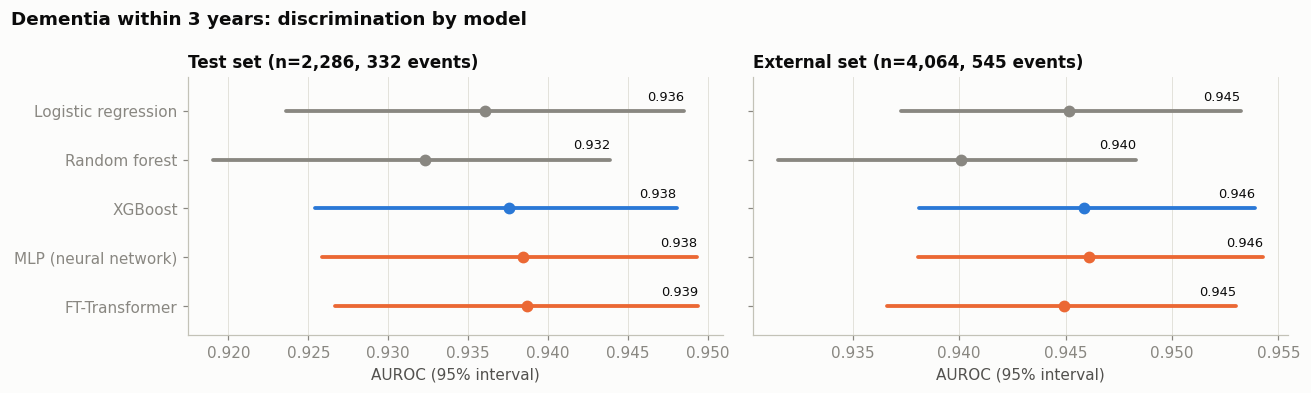

Highest test AUROC: FT-Transformer (0.939). Gap between best and worst model: 0.006.
Seed-to-seed spread of test AUROC: {'Random forest': 0.0003, 'XGBoost': 0.001, 'MLP (neural network)': 0.0022, 'FT-Transformer': 0.0018}


In [3]:
colors = {"Logistic regression": nu.MUTED, "Random forest": nu.MUTED, "XGBoost": nu.BLUE, "MLP (neural network)": nu.ORANGE, "FT-Transformer": nu.ORANGE}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, s in zip(axes, ["test", "external"]):
    interval_plot(ax, {k: v[s] for k, v in models.items()}, colors=colors)
    ax.set_title(f"{s.capitalize()} set (n={models['XGBoost'][s]['n']:,}, {models['XGBoost'][s]['events']} events)")
fig.suptitle("Dementia within 3 years: discrimination by model", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); nu.savefig(fig, "06_model_comparison"); plt.show()
best = max(models, key=lambda k: models[k]["test"]["auroc"])
spread = max(v["test"]["auroc"] for v in models.values()) - min(v["test"]["auroc"] for v in models.values())
print(f"Highest test AUROC: {best} ({models[best]['test']['auroc']:.3f}). Gap between best and worst model: {spread:.3f}.")
print("Seed-to-seed spread of test AUROC:", {k: round(float(np.ptp(v["test_auroc_per_seed"])), 4) for k, v in models.items() if v["seeds"] > 1})

**All five models perform the same.** Test AUROC runs from 0.932 to 0.939 and every interval overlaps every other. The gap between the best and worst model (about 0.007) is smaller than the uncertainty on any single one (about 0.012 either way).

* The FT-Transformer and the MLP are level with XGBoost and with plain logistic regression. Deep learning brings **no measurable gain** on this task.
* This is the usual finding for clinical tables of this size (about 11,000 training participants, 48 features), and published benchmarks of tabular deep learning report the same. It is not a sign that something was done wrong.
* Results on the 9 held-out centres are as good as on the internal test set (AUROC about 0.945), so the models transfer to centres they never saw.
* The FT-Transformer took about 20 minutes to train on CPU; logistic regression took seconds.

**What to conclude.** Reporting "we tried a transformer and it matched a logistic regression" is a stronger result than claiming a deep model is better without a baseline, because it shows the comparison was fair. For the rest of the project XGBoost is used as the main tabular model: it matches the best, handles missing values without imputation, trains in seconds, and has exact SHAP explanations. The deep models earn their place later, where the input is not a flat table (visit sequences, images, fusion).

### 1.1 The overall AUROC flatters every model

The cohort mixes people who start normal (about 1.6% convert) with people who start with MCI (about 41% convert). A "model" that only knew the starting diagnosis would already score well. The fairer question is how well a model ranks people **within** each group.

In [4]:
rows = {}
for k, v in models.items():
    rows[k] = {"All": v["test"]["auroc"], "Normal at index": v["test"]["normal_at_index"]["auroc"], "MCI at index": v["test"]["mci_at_index"]["auroc"],
               "External: all": v["external"]["auroc"], "External: normal": v["external"]["normal_at_index"]["auroc"], "External: MCI": v["external"]["mci_at_index"]["auroc"]}
sub = pd.DataFrame(rows).T.round(3)
x = models["XGBoost"]["test"]
print(f"Test set: normal at index n={x['normal_at_index']['n']}, events={x['normal_at_index']['events']}; MCI at index n={x['mci_at_index']['n']}, events={x['mci_at_index']['events']}")
sub

Test set: normal at index n=1411, events=24; MCI at index n=732, events=289


,All,Normal at index,MCI at index,External: all,External: normal,External: MCI
Logistic regression,0.936,0.838,0.844,0.945,0.875,0.843
Random forest,0.932,0.855,0.827,0.940,0.867,0.833
XGBoost,0.938,0.885,0.836,0.946,0.876,0.846
MLP (neural network),0.938,0.871,0.839,0.946,0.871,0.845
FT-Transformer,0.939,0.883,0.838,0.945,0.877,0.843


* Within people who start with **MCI**, AUROC is about 0.83 to 0.85, clearly lower than the headline 0.94. This is the honest measure of how well the model separates converters from non-converters among people at real risk.
* Within people who start **normal**, AUROC is about 0.84 to 0.89, but the test set holds only 24 converters in that group, so the intervals are wide (roughly 0.75 to 0.94). No model can be said to be better than another there.
* The headline 0.94 is partly "the model knows who has MCI". The report should always give the within-group numbers next to it.

### 1.2 Calibration: can the predicted risk be believed?

A model can rank people well and still give the wrong numbers (saying 60% when the truth is 30%). For a tool that shows a risk to a clinician, calibration matters as much as AUROC. Participants are sorted by predicted risk and cut into ten equal groups; for each group we compare the average predicted risk with the share who actually converted.

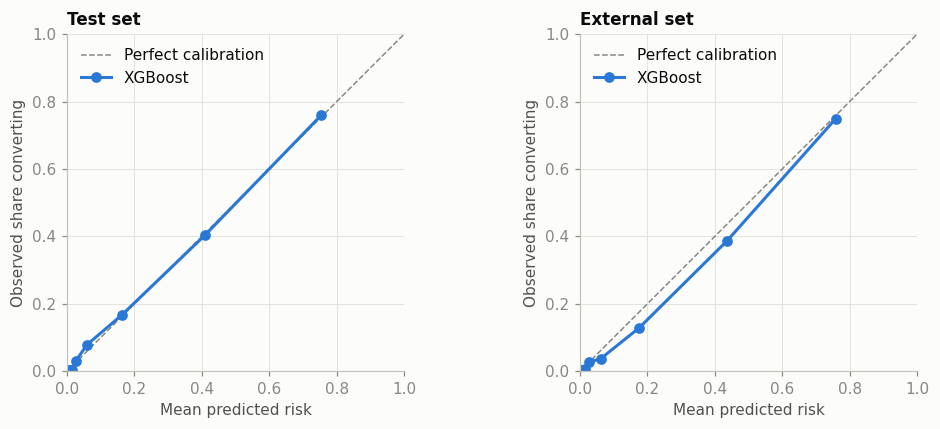

Brier score: XGBoost test 0.0663; always predicting the training event rate (0.147) gives 0.1241


,Participants,Mean predicted risk,Observed rate
0,229,0.0030,0.0000
1,229,0.0044,0.0044
2,228,0.0062,0.0000
3,229,0.0091,0.0044
4,228,0.0145,0.0044
5,229,0.0259,0.0306
6,228,0.0595,0.0789
7,229,0.1616,0.1659
8,228,0.4090,0.4035
9,229,0.7545,0.7598


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, s in zip(axes, ["test", "external"]):
    c = tab["calibration_xgboost"][s]
    ax.plot([0, 1], [0, 1], color=nu.MUTED, lw=1, ls="--", label="Perfect calibration")
    ax.plot(c["predicted"], c["observed"], marker="o", color=nu.BLUE, label="XGBoost")
    ax.set_xlabel("Mean predicted risk"); ax.set_ylabel("Observed share converting"); ax.set_title(f"{s.capitalize()} set"); ax.legend(loc="upper left")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
fig.tight_layout(); nu.savefig(fig, "06_calibration"); plt.show()
ref = tab["reference"]
print(f"Brier score: XGBoost test {models['XGBoost']['test']['brier']:.4f}; always predicting the training event rate ({ref['train_event_rate']:.3f}) gives {ref['brier_predicting_base_rate_test']:.4f}")
pd.DataFrame(tab["calibration_xgboost"]["test"]).rename(columns={"n": "Participants", "predicted": "Mean predicted risk", "observed": "Observed rate"})

The points lie close to the diagonal on the test set: when the model says about 41%, about 40% convert; when it says about 75%, about 76% do. On the external centres it slightly over-predicts in the upper-middle range (predicts 17.5%, observed 13%). The Brier score (0.066) is about half that of always predicting the base rate (0.124).

So the risks are usable as probabilities, with a small over-estimate at new centres that a recalibration step in the validation phase should correct.

## 2. What does each category add?

The same XGBoost setup is retrained on different sets of features and scored on the same test participants.

* **Alone**: only that group.
* **Cumulative**: groups added one after another, in the order a clinic would collect them.
* **Gain when added to all the others**: full model minus the model without that group. Because both models are scored on the same re-sampled participants, the interval is for the *difference*. If it includes zero, the group's contribution is not distinguishable from noise.

In [6]:
groups = list(tab["groups_alone"])
g = pd.DataFrame({"Features": {k: None for k in groups},
                  "AUROC alone": {k: tab["groups_alone"][k]["test"]["auroc"] for k in groups},
                  "AUROC cumulative": {k: tab["groups_cumulative"][k]["test"]["auroc"] for k in groups},
                  "AUPRC cumulative": {k: tab["groups_cumulative"][k]["test"]["auprc"] for k in groups},
                  "Gain when added to all others": {k: tab["groups_removed"][k]["test"]["delta_auroc"] for k in groups},
                  "Gain 95% low": {k: tab["groups_removed"][k]["test"]["delta_auroc_ci"][0] for k in groups},
                  "Gain 95% high": {k: tab["groups_removed"][k]["test"]["delta_auroc_ci"][1] for k in groups},
                  "External: gain": {k: tab["groups_removed"][k]["external"]["delta_auroc"] for k in groups},
                  "External: 95% low": {k: tab["groups_removed"][k]["external"]["delta_auroc_ci"][0] for k in groups},
                  "External: 95% high": {k: tab["groups_removed"][k]["external"]["delta_auroc_ci"][1] for k in groups}}).drop(columns="Features")
g.round(4)

,AUROC alone,AUROC cumulative,AUPRC cumulative,Gain when added to all others,Gain 95% low,Gain 95% high,External: gain,External: 95% low,External: 95% high
Demographics,0.6710,0.6710,0.2529,0.0099,0.0057,0.0147,0.0091,0.0060,0.0125
Genetics / APOE,0.6446,0.7216,0.3082,0.0028,0.0015,0.0044,0.0008,-0.0002,0.0019
Cardiovascular / medical,0.6255,0.7459,0.3405,0.0011,-0.0002,0.0025,0.0010,0.0000,0.0019
Cognitive tests,0.8957,0.9220,0.6687,0.0219,0.0153,0.0289,0.0188,0.0135,0.0239
"Clinical stage (CDR-SB, diagnosis)",0.8971,0.9372,0.7137,0.0152,0.0073,0.0229,0.0205,0.0147,0.0269


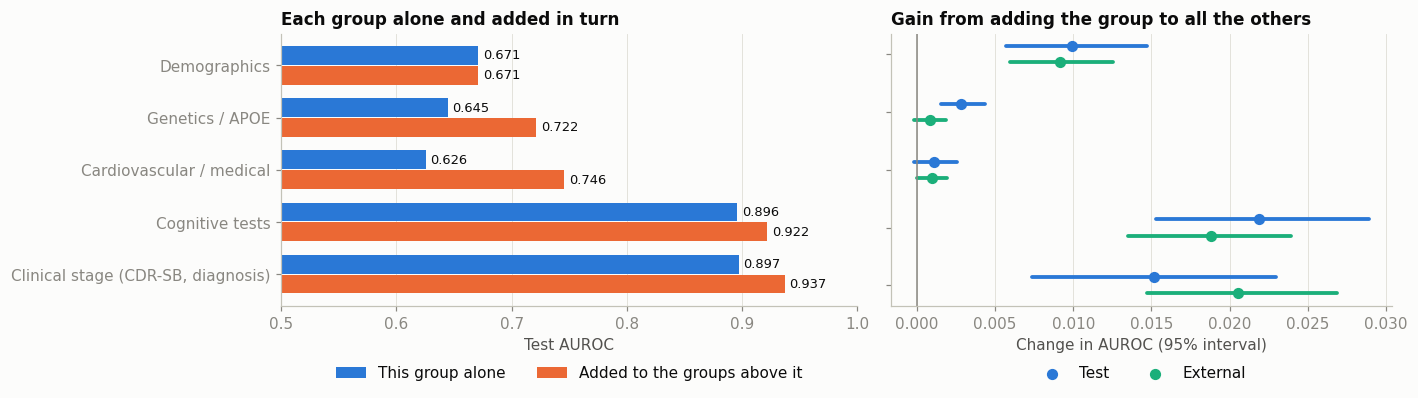

Cardiovascular group added to demographics + APOE only (test): AUROC 0.746, gain +0.0243 (95% interval +0.0112 to +0.0390)
Cardiovascular group added to demographics + APOE only (external): AUROC 0.744, gain +0.0043 (95% interval -0.0060 to +0.0147)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1.15, 1]})
ypos = np.arange(len(groups))[::-1]
axes[0].barh(ypos + 0.19, g["AUROC alone"], height=0.36, color=nu.BLUE, label="This group alone")
axes[0].barh(ypos - 0.19, g["AUROC cumulative"], height=0.36, color=nu.ORANGE, label="Added to the groups above it")
for yv, a, c in zip(ypos, g["AUROC alone"], g["AUROC cumulative"]):
    axes[0].text(a + 0.004, yv + 0.19, f"{a:.3f}", va="center", fontsize=8.5); axes[0].text(c + 0.004, yv - 0.19, f"{c:.3f}", va="center", fontsize=8.5)
axes[0].set_yticks(ypos, groups); axes[0].set_xlim(0.5, 1.0); axes[0].set_xlabel("Test AUROC"); axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=2); axes[0].grid(axis="y", visible=False)
axes[0].set_title("Each group alone and added in turn")
for s, color, off in [("test", nu.BLUE, 0.14), ("external", nu.AQUA, -0.14)]:
    for yv, k in zip(ypos, groups):
        m = tab["groups_removed"][k][s]
        axes[1].plot(m["delta_auroc_ci"], [yv + off] * 2, color=color, lw=2.5, solid_capstyle="round")
        axes[1].scatter([m["delta_auroc"]], [yv + off], color=color, s=40, zorder=3, label=s.capitalize() if yv == ypos[0] else None)
axes[1].axvline(0, color=nu.MUTED, lw=1); axes[1].set_yticks(ypos, [""] * len(groups)); axes[1].grid(axis="y", visible=False)
axes[1].set_xlabel("Change in AUROC (95% interval)"); axes[1].set_title("Gain from adding the group to all the others"); axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=2)
fig.tight_layout(); nu.savefig(fig, "06_feature_groups"); plt.show()
c = tab["cardio_over_demographics_apoe"]
for s in ["test", "external"]:
    print(f"Cardiovascular group added to demographics + APOE only ({s}): AUROC {c[s]['auroc']:.3f}, gain {c[s]['delta_auroc']:+.4f} "
          f"(95% interval {c[s]['delta_auroc_ci'][0]:+.4f} to {c[s]['delta_auroc_ci'][1]:+.4f})")

**Research question 1: do cardiovascular and medical features add predictive value?**

* **On top of everything else: almost nothing.** Adding the 25 cardiovascular features to a model that already has demographics, APOE, cognition and clinical stage changes AUROC by +0.001 on the test set (interval -0.0002 to +0.0025) and +0.001 on the external centres (interval 0.000 to +0.002). The test-set interval includes zero and the external one touches it. Whatever is there is a tenth of a percentage point of AUROC, too small to matter in practice.
* **On their own they do carry signal** (AUROC 0.63), mostly because they travel with age.
* **Before any cognitive information** (added to demographics + APOE only) they add +0.024 on the test set (interval +0.011 to +0.039), but only +0.004 on the external centres, where the interval includes zero. So even that early benefit did not hold up at unseen centres.

**The other groups.** Cognitive tests add the most (+0.022), then clinical stage (+0.015) and demographics (+0.010). APOE adds a small amount on the test set (+0.003) that does not reach significance on the external centres.

**How to state the finding.** "In NACC, once a participant's current cognition is known, late-life cardiovascular and medical records did not improve 3-year prediction of dementia." That is a clear, well-supported answer. It should be followed by its limits: NACC enrols at a median age of 71, so mid-life exposure (which the literature links most strongly to dementia) is not observed; the horizon is 3 years; and vascular damage may already be expressed *through* the cognitive scores. It is not a statement that vascular health is irrelevant to dementia.

### 2.1 The close-to-diagnosis variables

Daily function (FAQ), level of independence, memory complaints and whether the person is already on an Alzheimer's drug were kept out of the main model, because they are close to being the diagnosis itself. What happens if they are added?

In [8]:
p = tab["with_proximal"]
pd.DataFrame({s.capitalize(): {"AUROC without": p[s]["auroc"] - p[s]["delta_auroc"], "AUROC with": p[s]["auroc"],
                                "Gain": p[s]["delta_auroc"], "Gain 95% low": p[s]["delta_auroc_ci"][0], "Gain 95% high": p[s]["delta_auroc_ci"][1]}
              for s in ["test", "external"]}).round(4)

,Test,External
AUROC without,0.9372,0.9458
AUROC with,0.9428,0.9510
Gain,0.0056,0.0052
Gain 95% low,0.0028,0.0029
Gain 95% high,0.0089,0.0074


They add about +0.005 AUROC, and the interval excludes zero on both test sets. The gain is real but small, so the main model does **not** depend on these close-to-diagnosis variables. Keeping them out costs little and makes the "early prediction" claim cleaner. Both versions are reported so a reader can see this for themselves.

## 3. Does history help?

**Design.** A *landmark* is a visit where we pretend to make the prediction. Here it is any in-person visit at which the person is not demented, has **at least two earlier visits**, and has a known 3-year outcome. Training uses all landmarks of the training participants; the test uses one randomly chosen landmark per test participant, so each person counts once.

Three models, same test landmarks:

1. **XGBoost, landmark visit only**: no history at all.
2. **XGBoost + trajectory features**: adds the slope of each cognitive domain and CDR-SB over earlier visits, the change since the previous visit, and how many visits there were.
3. **GRU**: a recurrent neural network that reads up to six visits in order (with the time gap of each), joined with the landmark-visit features.

In [9]:
print("Landmarks:", {k: v for k, v in lon["landmarks"].items()})
print("Earlier visits at the test landmark:", lon["prior_visits_at_test_landmark"])
lm = lon["models"]
out = {}
for k, v in lm.items():
    for s in ["test", "external"]:
        r = row(v[s]); r["Gain in AUROC vs no history"] = "reference" if "delta_auroc" not in v[s] else f"{v[s]['delta_auroc']:+.4f} ({v[s]['delta_auroc_ci'][0]:+.4f} to {v[s]['delta_auroc_ci'][1]:+.4f})"
        out[(s.capitalize(), k)] = r
pd.DataFrame(out).T

Landmarks: {'train': {'n': 23025, 'participants': 5742, 'events': 2016}, 'val': {'n': 4661, 'participants': 1184, 'events': 385}, 'test': {'n': 1205, 'participants': 1205, 'events': 166}, 'external': {'n': 2254, 'participants': 2254, 'events': 326}}
Earlier visits at the test landmark: {'mean': 3.6, '50%': 3.0, 'max': 14.0}


,,AUROC,AUPRC,Brier,Gain in AUROC vs no history
Test,"XGBoost, landmark visit only",0.919 (0.896-0.942),0.711 (0.646-0.774),0.0684,reference
External,"XGBoost, landmark visit only",0.953 (0.942-0.963),0.787 (0.743-0.833),0.0573,reference
Test,XGBoost + trajectory features,0.922 (0.901-0.943),0.725 (0.655-0.788),0.0665,+0.0027 (-0.0064 to +0.0110)
External,XGBoost + trajectory features,0.956 (0.946-0.965),0.797 (0.753-0.839),0.0562,+0.0027 (-0.0010 to +0.0065)
Test,GRU over visit sequence,0.920 (0.897-0.942),0.735 (0.670-0.796),0.0654,+0.0002 (-0.0105 to +0.0099)
External,GRU over visit sequence,0.958 (0.948-0.967),0.814 (0.772-0.856),0.0537,+0.0047 (+0.0005 to +0.0083)


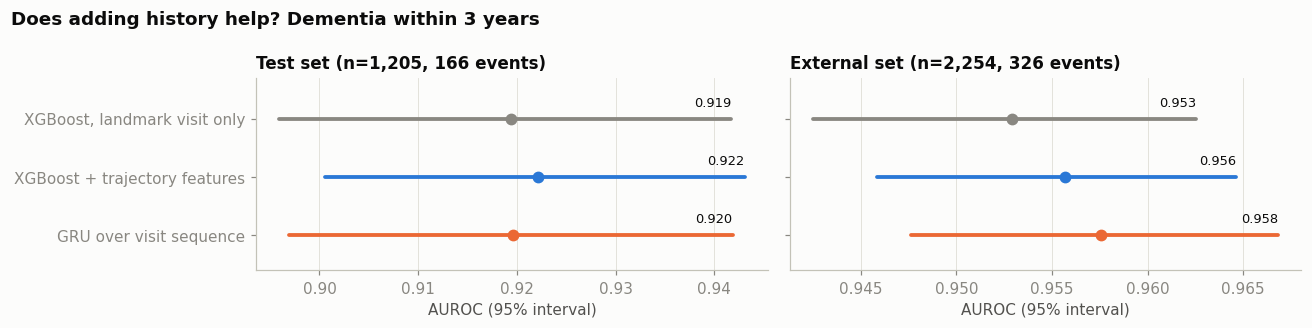

Participants Events  AUROC  \
2-3 prior visits XGBoost, landmark visit only           765    116   0.92   
                 XGBoost + trajectory features          765    116  0.922   
                 GRU over visit sequence                765    116  0.921   
4+ prior visits  XGBoost, landmark visit only           440     50  0.918   
                 XGBoost + trajectory features          440     50  0.922   
                 GRU over visit sequence                440     50   0.92   

                                                          Gain vs no history  
2-3 prior visits XGBoost, landmark visit only                      reference  
                 XGBoost + trajectory features  +0.0024 (-0.0072 to +0.0142)  
                 GRU over visit sequence        +0.0013 (-0.0106 to +0.0116)  
4+ prior visits  XGBoost, landmark visit only                      reference  
                 XGBoost + trajectory features  +0.0041 (-0.0093 to +0.0175)  
                 GRU over visit sequence        +0.0017 (-0.0208 to +0.0217)

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
colors = {"XGBoost, landmark visit only": nu.MUTED, "XGBoost + trajectory features": nu.BLUE, "GRU over visit sequence": nu.ORANGE}
for ax, s in zip(axes, ["test", "external"]):
    interval_plot(ax, {k: v[s] for k, v in lm.items()}, colors=colors)
    ax.set_title(f"{s.capitalize()} set (n={lm['GRU over visit sequence'][s]['n']:,}, {lm['GRU over visit sequence'][s]['events']} events)")
fig.suptitle("Does adding history help? Dementia within 3 years", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); nu.savefig(fig, "06_longitudinal"); plt.show()
h = {}
for label, d in lon["test_by_history_length"].items():
    for k, m in d.items():
        h[(label, k)] = {"Participants": m["n"], "Events": m["events"], "AUROC": round(m["auroc"], 3),
                         "Gain vs no history": "reference" if "delta_auroc" not in m else f"{m['delta_auroc']:+.4f} ({m['delta_auroc_ci'][0]:+.4f} to {m['delta_auroc_ci'][1]:+.4f})"}
pd.DataFrame(h).T

**Research question 3: does history help? Only very slightly.**

* Trajectory features add +0.003 AUROC on both test sets; neither interval excludes zero.
* The GRU adds nothing on the internal test set (+0.0002) and +0.005 on the external centres (interval +0.0005 to +0.008). That is the only comparison where history shows a measurable benefit, and it is small.
* For participants with four or more earlier visits the picture is the same, with wider intervals.

**Why so little?** The landmark visit already contains the *result* of the history. If someone has been declining, their current CDR-SB and memory score are already worse, and the model sees that. The slope tells the model how they got there, which adds little once it knows where they are. Histories are also short (a median of 3 earlier visits).

**What to conclude.** A recurrent network is not needed for accuracy here. The simple engineered slopes do as well, and keep SHAP explanations available. History still has a use in the interface, for showing a patient's trajectory ("how are they doing compared with last visit"), which is a description and not a prediction.

## 4. What these results do and do not show

**What the results show**

| Question | Answer | Evidence |
|---|---|---|
| Best model? | No difference between logistic regression, random forest, XGBoost, MLP and FT-Transformer | Test AUROC 0.932 to 0.939, overlapping intervals; same on 9 held-out centres |
| How good is it really? | AUROC about 0.84 among people with MCI at index; 0.94 overall | Within-group analysis |
| Are the risks calibrated? | Yes on the test set; slight over-estimate on external centres | Calibration tables |
| Do cardiovascular features add value? | Not meaningfully once cognition is known | Gain about +0.001 AUROC |
| Does history add value? | Marginally at most | Gain +0.003 to +0.005 |

**What they do not show**

* Nothing here is clinical validation. These are retrospective results on research volunteers.
* The models were tuned lightly (a few settings each, chosen on the validation split). More tuning would be unlikely to separate models that are this close, but it has not been tried.
* The cohort leaves out people whose 3-year status is unknown (about half of those eligible). The survival-analysis check in the validation phase will test whether that matters.
* The first-visit test set contains only 24 converters among people who started normal, so claims about predicting decline in cognitively normal people are weak.

**Decisions this opens for the team**

1. Keep XGBoost as the main tabular model (recommended), or present a deep model as the headline knowing it is not better.
2. Whether to try a longer horizon (5 years) or a cognitively-normal-only cohort, where cardiovascular features have more room to matter.
3. Whether to keep the GRU in the final system or report it as a tested alternative.